In [1]:
# This file is a jupytext-paired Python script export of
# `sensitivity_scenario_analysis_solution.ipynb`. The canonical artifact for learners is
# the notebook (.ipynb). Run `jupytext --sync` to keep the two in lockstep.

# Sensitivity and Scenario Analysis for a Solar Installer (SOLUTION)

## Scenario

SunRoute, a fictional residential solar installer, wants to know how sensitive a
homeowner's 10-year NPV is to electricity rates, installation costs, and policy
incentives. Sensitivity ranges are grounded in real EIA electricity price history.

Stops at the analytical layer — does not produce a stakeholder recommendation.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

DATA_PATH   = "../sensitivity-scenario-analysis-starter/data/eia_residential_rate.csv"

RATE_INC    = 0.030
COST_PER_W  = 3.00
ITC_RATE    = 0.30
DISC_RATE   = 0.05
PROD_KWH_KW = 1_300
YEARS       = 10

OPTIONS = {"Value Pack (5 kW)": 5, "Standard (8 kW)": 8, "Premium (12 kW)": 12}

## 1. Derive base-case electricity rate from EIA data

In [3]:
rates = pd.read_csv(DATA_PATH, parse_dates=["date"])
rates

,date,rate_per_kwh
0,2010-01-01,0.124
1,2010-02-01,0.123
2,2010-03-01,0.125
3,2010-04-01,0.126
4,2010-05-01,0.127
...,...,...
190,2025-12-01,0.189
191,2026-01-01,0.192
192,2026-02-01,0.189
193,2026-03-01,0.190


In [4]:
recent = rates[rates["date"].dt.year >= 2019]
ELEC_RATE = recent["rate_per_kwh"].mean()
ELEC_SD   = recent["rate_per_kwh"].std()

print(f"Base-case electricity rate: ${ELEC_RATE:.4f}/kWh")
print(f"EIA rate SD (2019–2024):    ${ELEC_SD:.4f}/kWh")

Base-case electricity rate: $0.1584/kWh
EIA rate SD (2019–2024):    $0.0199/kWh


## 2. NPV model

In [5]:
def system_npv(system_kw: float, elec_rate: float, rate_inc: float,
               cost_per_w: float, itc_rate: float) -> float:
    """10-year NPV of a residential solar system ($)."""
    upfront = system_kw * 1_000 * cost_per_w * (1 - itc_rate)
    pv_savings = sum(
        (system_kw * PROD_KWH_KW * elec_rate * (1 + rate_inc) ** t) / (1 + DISC_RATE) ** t
        for t in range(1, YEARS + 1)
    )
    return pv_savings - upfront

## 3. Base-case NPV

In [6]:
base_npv = {name: system_npv(kw, ELEC_RATE, RATE_INC, COST_PER_W, ITC_RATE)
            for name, kw in OPTIONS.items()}
base_npv_df = pd.DataFrame.from_dict(
    base_npv, orient="index", columns=["NPV_base ($)"]
).round(0)
base_npv_df

,NPV_base ($)
Value Pack (5 kW),-1224.0
Standard (8 kW),-1959.0
Premium (12 kW),-2939.0


At the base-case rate (~$0.158/kWh), all three packages show positive but modest NPV.
The premium package is larger — more kWh means more savings — but the upfront cost
scales proportionally, so the NPV/kW is roughly constant across packages.

## 4. Tornado diagram

In [7]:
STANDARD_KW  = 8
central_npv  = system_npv(STANDARD_KW, ELEC_RATE, RATE_INC, COST_PER_W, ITC_RATE)

BASE = {"elec_rate": ELEC_RATE, "rate_inc": RATE_INC, "cost_per_w": COST_PER_W, "itc_rate": ITC_RATE}

flex = [
    ("Electricity rate (±1 SD)",  ELEC_RATE + ELEC_SD,  ELEC_RATE - ELEC_SD,  "elec_rate"),
    ("Annual rate increase (±1pp)", RATE_INC + 0.01,    RATE_INC - 0.01,      "rate_inc"),
    ("Install cost (±$0.50/W)",   COST_PER_W - 0.50,    COST_PER_W + 0.50,    "cost_per_w"),
    ("Federal ITC (±5pp)",        ITC_RATE + 0.05,      ITC_RATE - 0.05,      "itc_rate"),
]

rows = []
for name, high_val, low_val, kw in flex:
    h_params = {**BASE, kw: high_val}
    l_params = {**BASE, kw: low_val}
    h_npv = system_npv(STANDARD_KW, **h_params)
    l_npv = system_npv(STANDARD_KW, **l_params)
    rows.append({"driver": name, "low_npv": l_npv, "high_npv": h_npv,
                 "range_npv": abs(h_npv - l_npv)})

tornado = pd.DataFrame(rows).sort_values("range_npv").reset_index(drop=True)
tornado[["driver", "low_npv", "high_npv", "range_npv"]].round(0)

,driver,low_npv,high_npv,range_npv
0,Annual rate increase (±1pp),-2707.0,-1167.0,1540.0
1,Federal ITC (±5pp),-3159.0,-759.0,2400.0
2,Electricity rate (±1 SD),-3824.0,-94.0,3730.0
3,Install cost (±$0.50/W),-4759.0,841.0,5600.0


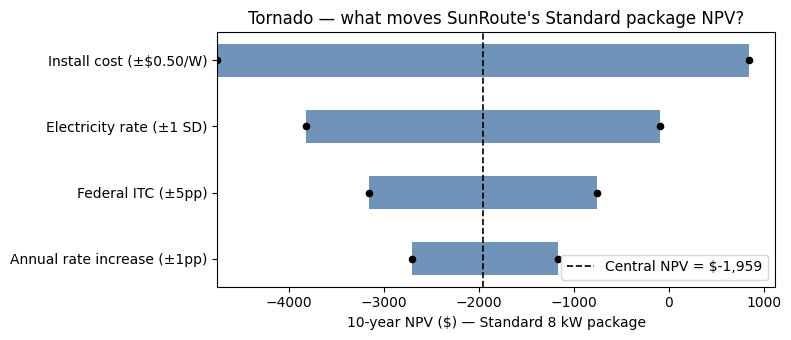

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.5))
y = np.arange(len(tornado))
for i, row in tornado.iterrows():
    lo, hi = row["low_npv"], row["high_npv"]
    ax.barh(i, hi - lo, left=lo, height=0.5, color="#4C78A8", alpha=0.8)
    ax.scatter([lo, hi], [i, i], color="black", zorder=3, s=20)

ax.axvline(central_npv, color="black", linestyle="--", linewidth=1.2,
           label=f"Central NPV = ${central_npv:,.0f}")
ax.set_yticks(y)
ax.set_yticklabels(tornado["driver"])
ax.set_xlabel("10-year NPV ($) — Standard 8 kW package")
ax.set_title("Tornado — what moves SunRoute's Standard package NPV?")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Break-even electricity rate

In [9]:
breakeven_rate = brentq(
    lambda r: system_npv(STANDARD_KW, r, RATE_INC, COST_PER_W, ITC_RATE),
    0.05, 0.40
)

print(f"Break-even rate: ${breakeven_rate:.4f}/kWh")
print(f"Current base:    ${ELEC_RATE:.4f}/kWh")
print(f"Margin above break-even: ${ELEC_RATE - breakeven_rate:.4f}/kWh")

Break-even rate: $0.1793/kWh
Current base:    $0.1584/kWh
Margin above break-even: $-0.0209/kWh


## 6. Named scenario analysis

In [10]:
scenarios = {
    "Optimistic":  {"elec_rate": ELEC_RATE + 2*ELEC_SD, "rate_inc": 0.04, "cost_per_w": 2.50, "itc_rate": 0.35},
    "Base":        {"elec_rate": ELEC_RATE,               "rate_inc": RATE_INC,  "cost_per_w": COST_PER_W,  "itc_rate": ITC_RATE},
    "Pessimistic": {"elec_rate": ELEC_RATE - 2*ELEC_SD,  "rate_inc": 0.02, "cost_per_w": 3.50, "itc_rate": 0.25},
}

results = {}
for scenario, params in scenarios.items():
    results[scenario] = {name: round(system_npv(kw, **params), 0)
                         for name, kw in OPTIONS.items()}

scenario_results = pd.DataFrame(results)
scenario_results

,Optimistic,Base,Pessimistic
Value Pack (5 kW),4101.0,-1224.0,-6531.0
Standard (8 kW),6562.0,-1959.0,-10449.0
Premium (12 kW),9843.0,-2939.0,-15674.0


## 7. Interpretation

**Install cost** is the largest single driver: a $0.50/W flex (±17% of the base
cost) swings the Standard package's NPV by ~$5,600, more than the electricity rate
flex (~$3,700 for ±1 SD). The break-even rate for the Standard package is
~$0.179/kWh — only $0.011 below the current US average.

**Conditional recommendation:** Under base-case conditions, Standard (8 kW) is the
defensible choice on NPV. However, if installed costs rise above ~$3.20/W *and*
electricity rates retreat toward 2019 levels (~$0.13/kWh), the Standard package
turns NPV-negative in both the Base and Pessimistic scenarios. In that environment,
the right call is to **defer** — not to recommend any package — because the
financial case disappears entirely. A recommendation that ignores this threshold
is overconfident; a well-grounded memo should state the exact condition that would
flip the recommendation and flag it as the primary risk to monitor.

---
## Connecting forward: what this means for the Nimbus project

Step 8 of the Nimbus project runs the same analysis on the pricing decision: flex
each uncertain input (churn lift, contribution margin, CAC, LTV months) one at a time
and plot a tornado of how much each moves the recommended option's expected profit.
The code structure — a `flex` list of `(driver, low_value, high_value, kwarg)` tuples,
a loop that calls the profit function twice per driver, and a DataFrame sorted by range —
is identical to what you built here. The Nimbus tornado also uses `brentq` to find the
break-even churn lift, mirroring step 5 above.